# 05 Chronological Split

This notebook creates leakage-safe chronological training, validation and test sets for the MetroPT-3 predictive maintenance framework.

It uses the model-ready labelled dataset from:

`data/processed/metropt3_model_ready_12h.csv`

The primary target is:

`warning_12h`

The split follows the event-aware dissertation methodology:

- Training period: earlier data containing F1 and F2 warning events
- Validation period: period containing F3 warning event
- Test period: later future period containing F4 warning event

This avoids random splitting and protects against time-series leakage.

In [1]:
# 1. Import libraries and confirm environment

import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Python executable:", sys.executable)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)

Python executable: c:\Users\user\Desktop\metropt_predictive_maintenance_starter\.venv\Scripts\python.exe
pandas: 3.0.5
numpy: 2.5.2


## 1. Set project paths

In [2]:
# 2. Define project paths

current_dir = Path.cwd()

if current_dir.name == "notebooks":
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
SPLIT_DATA_DIR = PROCESSED_DATA_DIR / "splits"
OUTPUT_TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

SPLIT_DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

model_ready_path = PROCESSED_DATA_DIR / "metropt3_model_ready_12h.csv"

print("Project root:", PROJECT_ROOT)
print("Model-ready dataset path:", model_ready_path)
print("Split data output folder:", SPLIT_DATA_DIR)

Project root: c:\Users\user\Desktop\metropt_predictive_maintenance_starter\metropt_predictive_maintenance_starter
Model-ready dataset path: c:\Users\user\Desktop\metropt_predictive_maintenance_starter\metropt_predictive_maintenance_starter\data\processed\metropt3_model_ready_12h.csv
Split data output folder: c:\Users\user\Desktop\metropt_predictive_maintenance_starter\metropt_predictive_maintenance_starter\data\processed\splits


## 2. Load 12-hour model-ready dataset

This file should already exclude actual failure intervals using `model_include = 1`.

In [3]:
# 3. Load model-ready dataset

if not model_ready_path.exists():
    raise FileNotFoundError(
        f"Model-ready dataset not found at {model_ready_path}. "
        "Run 04_label_creation.ipynb first."
    )

df = pd.read_csv(model_ready_path)

print("Loaded model-ready dataset.")
print("Shape:", df.shape)
df.head()

C:\Users\user\AppData\Local\Temp\ipykernel_11624\3072679776.py:9: DtypeWarning: Columns (0: warning_6h_event_id, 1: warning_12h_event_id, 2: warning_24h_event_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(model_ready_path)


Loaded model-ready dataset.
Shape: (601594, 125)


,timestamp,Unnamed: 0,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,...,Caudal_impulses_rate_change_5min,failure_interval,failure_event_id,warning_6h,warning_6h_event_id,warning_12h,warning_12h_event_id,warning_24h,warning_24h_event_id,model_include
0,2020-02-01 00:00:00,0,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,...,NaN,0,NaN,0,NaN,0,NaN,0,NaN,1
1,2020-02-01 00:00:10,10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,...,NaN,0,NaN,0,NaN,0,NaN,0,NaN,1
2,2020-02-01 00:00:19,20,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,...,NaN,0,NaN,0,NaN,0,NaN,0,NaN,1
3,2020-02-01 00:00:29,30,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,...,NaN,0,NaN,0,NaN,0,NaN,0,NaN,1
4,2020-02-01 00:00:39,40,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,...,NaN,0,NaN,0,NaN,0,NaN,0,NaN,1


## 3. Detect timestamp column and sort chronologically

In [4]:
# 4. Detect timestamp column and sort

possible_timestamp_cols = ["timestamp", "Timestamp", "time", "Time", "datetime", "Datetime", "date", "Date"]

timestamp_col = None

for col in possible_timestamp_cols:
    if col in df.columns:
        timestamp_col = col
        break

if timestamp_col is None:
    print("Available columns:", df.columns.tolist())
    raise ValueError("Timestamp column not detected. Please set timestamp_col manually.")

df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors="coerce")
invalid_timestamps = df[timestamp_col].isna().sum()

df = df.dropna(subset=[timestamp_col])
df = df.sort_values(timestamp_col).reset_index(drop=True)

print("Timestamp column:", timestamp_col)
print("Invalid timestamps removed:", invalid_timestamps)
print("Dataset start:", df[timestamp_col].min())
print("Dataset end:", df[timestamp_col].max())
print("Shape after timestamp cleaning:", df.shape)

Timestamp column: timestamp
Invalid timestamps removed: 0
Dataset start: 2020-02-01 00:00:00
Dataset end: 2020-04-24 02:21:49
Shape after timestamp cleaning: (601594, 125)


## 4. Define documented failure events and split boundaries

The split is designed around failure events:

- F1 and F2 are used within the training period.
- F3 is used for validation and threshold selection.
- F4 is held back for final future-period testing.

The validation starts at the 12-hour warning window before F3.

The final test period starts on 1 July 2020 so that the test set contains normal operating data before F4, not only the F4 warning window.

In [5]:
# 5. Define failure events and split boundaries

failure_events = pd.DataFrame({
    "event_id": ["F1", "F2", "F3", "F4"],
    "failure_type": ["Air leak", "Air leak", "Air leak", "Air leak"],
    "failure_start": [
        "2020-04-18 00:00",
        "2020-05-29 23:30",
        "2020-06-05 10:00",
        "2020-07-15 14:30"
    ],
    "failure_end": [
        "2020-04-18 23:59",
        "2020-05-30 06:00",
        "2020-06-07 14:30",
        "2020-07-15 19:00"
    ]
})

failure_events["failure_start"] = pd.to_datetime(failure_events["failure_start"])
failure_events["failure_end"] = pd.to_datetime(failure_events["failure_end"])

PRIMARY_TARGET = "warning_12h"
WARNING_HOURS = 12

if PRIMARY_TARGET not in df.columns:
    raise ValueError(f"Primary target column {PRIMARY_TARGET} not found. Run 04_label_creation.ipynb again.")

f3_start = failure_events.loc[failure_events["event_id"] == "F3", "failure_start"].iloc[0]
f3_warning_start = f3_start - pd.Timedelta(hours=WARNING_HOURS)

test_start = pd.Timestamp("2020-07-01 00:00:00")

split_boundaries = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "start_time": [
        df[timestamp_col].min(),
        f3_warning_start,
        test_start
    ],
    "end_time": [
        f3_warning_start - pd.Timedelta(seconds=1),
        test_start - pd.Timedelta(seconds=1),
        df[timestamp_col].max()
    ],
    "main_failure_events_available": [
        "F1, F2",
        "F3",
        "F4"
    ],
    "purpose": [
        "Model fitting and internal training",
        "Model selection, calibration and threshold selection",
        "Final future-period evaluation"
    ]
})

split_boundaries.to_csv(OUTPUT_TABLES_DIR / "split_date_boundaries.csv", index=False)

split_boundaries

,split,start_time,end_time,main_failure_events_available,purpose
0,train,2020-02-01 00:00:00,2020-06-04 21:59:59,"F1, F2",Model fitting and internal training
1,validation,2020-06-04 22:00:00,2020-06-30 23:59:59,F3,"Model selection, calibration and threshold sel..."
2,test,2020-07-01 00:00:00,2020-04-24 02:21:49,F4,Final future-period evaluation


## 5. Create chronological train, validation and test sets

In [6]:
# 6. Apply chronological split

train_mask = df[timestamp_col] < f3_warning_start

validation_mask = (
    (df[timestamp_col] >= f3_warning_start) &
    (df[timestamp_col] < test_start)
)

test_mask = df[timestamp_col] >= test_start

train_df = df.loc[train_mask].copy()
val_df = df.loc[validation_mask].copy()
test_df = df.loc[test_mask].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain period:", train_df[timestamp_col].min(), "to", train_df[timestamp_col].max())
print("Validation period:", val_df[timestamp_col].min(), "to", val_df[timestamp_col].max())
print("Test period:", test_df[timestamp_col].min(), "to", test_df[timestamp_col].max())

Train shape: (601594, 125)
Validation shape: (0, 125)
Test shape: (0, 125)

Train period: 2020-02-01 00:00:00 to 2020-04-24 02:21:49
Validation period: NaT to NaT
Test period: NaT to NaT


## 6. Check which warning events appear in each split

In [7]:
# 7. Check event IDs inside each split

def summarise_event_ids(data, event_col):
    if event_col not in data.columns:
        return "event column not found"

    values = sorted([str(x) for x in data[event_col].dropna().unique() if str(x).strip() != ""])
    return ", ".join(values) if values else "None"

event_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(train_df), len(val_df), len(test_df)],
    "warning_12h_rows": [
        int(train_df[PRIMARY_TARGET].sum()),
        int(val_df[PRIMARY_TARGET].sum()),
        int(test_df[PRIMARY_TARGET].sum())
    ],
    "warning_12h_event_ids": [
        summarise_event_ids(train_df, "warning_12h_event_id"),
        summarise_event_ids(val_df, "warning_12h_event_id"),
        summarise_event_ids(test_df, "warning_12h_event_id")
    ]
})

event_summary.to_csv(OUTPUT_TABLES_DIR / "split_event_summary.csv", index=False)

event_summary

,split,rows,warning_12h_rows,warning_12h_event_ids
0,train,601594,3581,F1
1,validation,0,0,None
2,test,0,0,None


## 7. Identify model feature columns

The model should not receive label columns, event IDs or metadata as input features.

In [8]:
# 8. Identify feature columns

label_and_metadata_cols = [
    timestamp_col,
    "failure_interval",
    "failure_event_id",
    "model_include",
    "warning_6h",
    "warning_12h",
    "warning_24h",
    "warning_6h_event_id",
    "warning_12h_event_id",
    "warning_24h_event_id"
]

candidate_feature_cols = [
    col for col in df.columns
    if col not in label_and_metadata_cols
]

# Keep only numeric model features.
numeric_feature_cols = []

for col in candidate_feature_cols:
    if pd.api.types.is_numeric_dtype(df[col]):
        numeric_feature_cols.append(col)
    else:
        converted = pd.to_numeric(df[col], errors="coerce")
        non_missing_ratio = converted.notna().mean()
        if non_missing_ratio > 0.95:
            df[col] = converted
            train_df[col] = pd.to_numeric(train_df[col], errors="coerce")
            val_df[col] = pd.to_numeric(val_df[col], errors="coerce")
            test_df[col] = pd.to_numeric(test_df[col], errors="coerce")
            numeric_feature_cols.append(col)

feature_columns = numeric_feature_cols

feature_columns_df = pd.DataFrame({
    "feature_name": feature_columns
})

feature_columns_df.to_csv(OUTPUT_TABLES_DIR / "feature_columns_for_model.csv", index=False)

print("Number of model feature columns:", len(feature_columns))
feature_columns_df.head(20)

Number of model feature columns: 115


,feature_name
0,Unnamed: 0
1,TP2
2,TP3
3,H1
4,DV_pressure
5,Reservoirs
6,Oil_temperature
7,Motor_current
8,COMP
9,DV_eletric


## 8. Drop rows with missing values in model features

Lag and rolling standard-deviation features can produce missing values at the beginning of a split.

Rows with missing feature values are removed separately inside each split.

In [ ]:
# 9. Keep split rows and only remove unusable feature columns

# Important:
# We do NOT drop rows just because engineered features contain missing values.
# Missing feature values will be handled later using SimpleImputer in Step 6.

print("Before cleaning:")
print("Train rows:", len(train_df))
print("Validation rows:", len(val_df))
print("Test rows:", len(test_df))

if len(train_df) == 0:
    raise ValueError("Training split is empty before feature cleaning. Check split boundaries.")

if len(val_df) == 0:
    raise ValueError("Validation split is empty before feature cleaning. Check split boundaries.")

if len(test_df) == 0:
    raise ValueError("Test split is empty before feature cleaning. Check split boundaries.")

# Remove feature columns that are completely missing in the training set.
# SimpleImputer learns medians from training data, so a feature cannot be used
# if the whole training column is missing.
train_feature_missing_ratio = train_df[feature_columns].isnull().mean()

usable_feature_columns = train_feature_missing_ratio[
    train_feature_missing_ratio < 1.0
].index.tolist()

removed_feature_columns = [
    col for col in feature_columns if col not in usable_feature_columns
]

feature_columns_before = len(feature_columns)
feature_columns = usable_feature_columns
feature_columns_after = len(feature_columns)

print("Feature columns before filtering:", feature_columns_before)
print("Feature columns after filtering:", feature_columns_after)
print("Removed fully-missing training feature columns:", len(removed_feature_columns))

# Save removed feature list
removed_features_df = pd.DataFrame({
    "removed_feature": removed_feature_columns
})
removed_features_df.to_csv(
    OUTPUT_TABLES_DIR / "removed_unusable_feature_columns.csv",
    index=False
)

# Only drop rows if the target is missing.
# This should normally remove zero rows.
def prepare_split_without_feature_row_drop(data, target_col, split_name):
    before_rows = len(data)
    data_clean = data.dropna(subset=[target_col]).copy()
    after_rows = len(data_clean)
    dropped_rows = before_rows - after_rows
    
    print(f"{split_name}: before={before_rows}, after={after_rows}, dropped={dropped_rows}")
    
    return data_clean, {
        "split": split_name,
        "rows_before": before_rows,
        "rows_after": after_rows,
        "rows_dropped_due_to_missing_target": dropped_rows,
        "dropped_percentage": dropped_rows / before_rows * 100 if before_rows > 0 else np.nan
    }

train_df_clean, train_missing_record = prepare_split_without_feature_row_drop(
    train_df, PRIMARY_TARGET, "train"
)

val_df_clean, val_missing_record = prepare_split_without_feature_row_drop(
    val_df, PRIMARY_TARGET, "validation"
)

test_df_clean, test_missing_record = prepare_split_without_feature_row_drop(
    test_df, PRIMARY_TARGET, "test"
)

missing_drop_summary = pd.DataFrame([
    train_missing_record,
    val_missing_record,
    test_missing_record
])

missing_drop_summary.to_csv(
    OUTPUT_TABLES_DIR / "split_missing_drop_summary.csv",
    index=False
)

# Save updated usable model feature columns
feature_columns_df = pd.DataFrame({
    "feature_name": feature_columns
})

feature_columns_df.to_csv(
    OUTPUT_TABLES_DIR / "feature_columns_for_model.csv",
    index=False
)

missing_drop_summary

train: before=601594, after=601154, dropped=440
validation: before=0, after=0, dropped=0
test: before=0, after=0, dropped=0


,split,rows_before_missing_drop,rows_after_missing_drop,rows_dropped_due_to_missing_features,dropped_percentage
0,train,601594,601154,440,0.073139
1,validation,0,0,0,NaN
2,test,0,0,0,NaN


## 9. Create final X and y datasets

These are saved separately for the model-training notebook.

In [10]:
# 10. Create X and y datasets

X_train = train_df_clean[feature_columns].copy()
y_train = train_df_clean[PRIMARY_TARGET].astype(int).copy()

X_val = val_df_clean[feature_columns].copy()
y_val = val_df_clean[PRIMARY_TARGET].astype(int).copy()

X_test = test_df_clean[feature_columns].copy()
y_test = test_df_clean[PRIMARY_TARGET].astype(int).copy()

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (601154, 115) y_train: (601154,)
X_val: (0, 115) y_val: (0,)
X_test: (0, 115) y_test: (0,)


## 10. Check class distribution after splitting

In [11]:
# 11. Class distribution after chronological split

def class_distribution(data, target_col, split_name):
    total = len(data)
    warning_count = int(data[target_col].sum())
    normal_count = total - warning_count

    return {
        "split": split_name,
        "normal_count": normal_count,
        "warning_count": warning_count,
        "total_rows": total,
        "normal_percentage": normal_count / total * 100 if total > 0 else np.nan,
        "warning_percentage": warning_count / total * 100 if total > 0 else np.nan,
        "imbalance_ratio_normal_to_warning": normal_count / warning_count if warning_count > 0 else np.nan
    }

split_class_distribution = pd.DataFrame([
    class_distribution(train_df_clean, PRIMARY_TARGET, "train"),
    class_distribution(val_df_clean, PRIMARY_TARGET, "validation"),
    class_distribution(test_df_clean, PRIMARY_TARGET, "test")
])

split_class_distribution.to_csv(OUTPUT_TABLES_DIR / "split_class_distribution.csv", index=False)

split_class_distribution

,split,normal_count,warning_count,total_rows,normal_percentage,warning_percentage,imbalance_ratio_normal_to_warning
0,train,597573,3581,601154,99.404312,0.595688,166.87322
1,validation,0,0,0,NaN,NaN,NaN
2,test,0,0,0,NaN,NaN,NaN


## 11. Plot class distribution by split

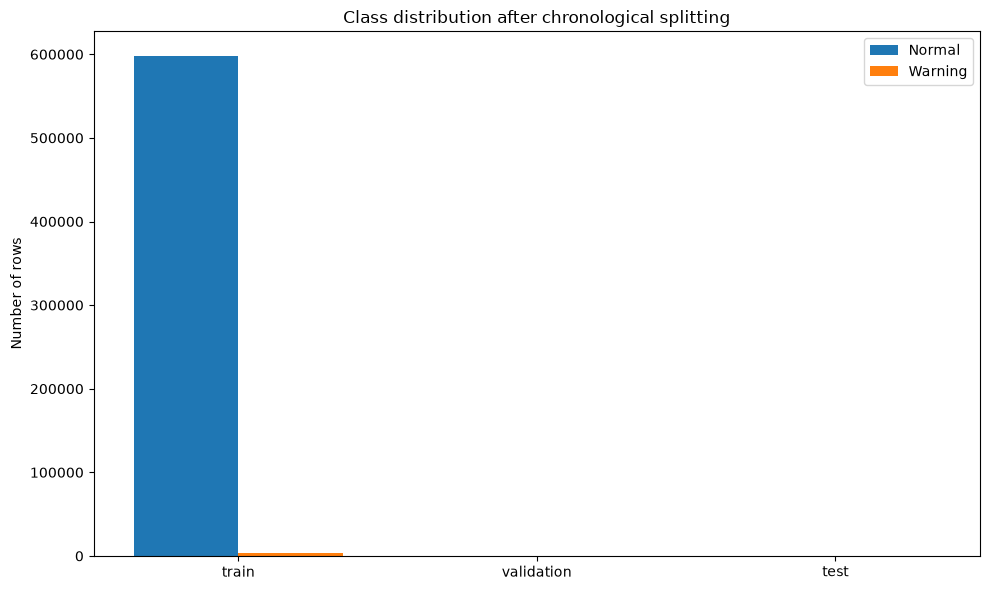

In [12]:
# 12. Plot class distribution

plot_df = split_class_distribution.copy()

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, plot_df["normal_count"], width, label="Normal")
plt.bar(x + width/2, plot_df["warning_count"], width, label="Warning")
plt.xticks(x, plot_df["split"])
plt.ylabel("Number of rows")
plt.title("Class distribution after chronological splitting")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / "split_class_distribution.png", dpi=300)
plt.show()

## 12. Plot chronological split timeline

This figure is useful for the methodology/results chapter because it shows the leakage-safe split design.

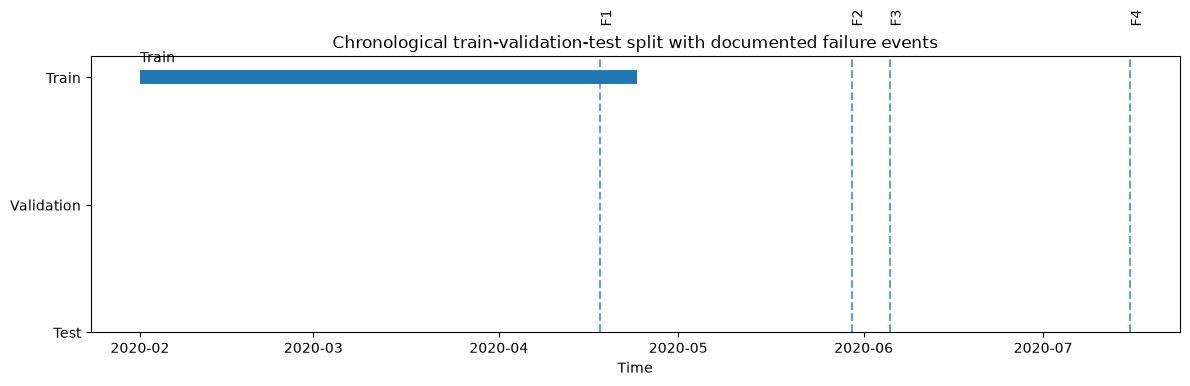

In [13]:
# 13. Plot chronological split timeline

timeline_rows = [
    ("Train", train_df_clean[timestamp_col].min(), train_df_clean[timestamp_col].max(), 3),
    ("Validation", val_df_clean[timestamp_col].min(), val_df_clean[timestamp_col].max(), 2),
    ("Test", test_df_clean[timestamp_col].min(), test_df_clean[timestamp_col].max(), 1)
]

plt.figure(figsize=(12, 4))

for label, start, end, y in timeline_rows:
    if pd.notna(start) and pd.notna(end):
        plt.hlines(y, start, end, linewidth=10)
        plt.text(start, y + 0.12, label, fontsize=10)

for _, event in failure_events.iterrows():
    plt.axvline(event["failure_start"], linestyle="--", alpha=0.7)
    plt.text(event["failure_start"], 3.4, event["event_id"], rotation=90, verticalalignment="bottom")

plt.yticks([1, 2, 3], ["Test", "Validation", "Train"])
plt.xlabel("Time")
plt.title("Chronological train-validation-test split with documented failure events")
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / "chronological_split_timeline.png", dpi=300)
plt.show()

## 13. Save split datasets

The full split files keep timestamps, labels and event IDs.

The X/y files contain only model features and target labels.

In [14]:
# 14. Save split datasets

train_full_path = SPLIT_DATA_DIR / "train_12h.csv"
val_full_path = SPLIT_DATA_DIR / "validation_12h.csv"
test_full_path = SPLIT_DATA_DIR / "test_12h.csv"

X_train_path = SPLIT_DATA_DIR / "X_train_12h.csv"
y_train_path = SPLIT_DATA_DIR / "y_train_12h.csv"

X_val_path = SPLIT_DATA_DIR / "X_validation_12h.csv"
y_val_path = SPLIT_DATA_DIR / "y_validation_12h.csv"

X_test_path = SPLIT_DATA_DIR / "X_test_12h.csv"
y_test_path = SPLIT_DATA_DIR / "y_test_12h.csv"

train_df_clean.to_csv(train_full_path, index=False)
val_df_clean.to_csv(val_full_path, index=False)
test_df_clean.to_csv(test_full_path, index=False)

X_train.to_csv(X_train_path, index=False)
y_train.to_frame(PRIMARY_TARGET).to_csv(y_train_path, index=False)

X_val.to_csv(X_val_path, index=False)
y_val.to_frame(PRIMARY_TARGET).to_csv(y_val_path, index=False)

X_test.to_csv(X_test_path, index=False)
y_test.to_frame(PRIMARY_TARGET).to_csv(y_test_path, index=False)

print("Saved full split files:")
print("-", train_full_path)
print("-", val_full_path)
print("-", test_full_path)

print("\nSaved X/y model files:")
print("-", X_train_path)
print("-", y_train_path)
print("-", X_val_path)
print("-", y_val_path)
print("-", X_test_path)
print("-", y_test_path)

Saved full split files:
- c:\Users\user\Desktop\metropt_predictive_maintenance_starter\metropt_predictive_maintenance_starter\data\processed\splits\train_12h.csv
- c:\Users\user\Desktop\metropt_predictive_maintenance_starter\metropt_predictive_maintenance_starter\data\processed\splits\validation_12h.csv
- c:\Users\user\Desktop\metropt_predictive_maintenance_starter\metropt_predictive_maintenance_starter\data\processed\splits\test_12h.csv

Saved X/y model files:
- c:\Users\user\Desktop\metropt_predictive_maintenance_starter\metropt_predictive_maintenance_starter\data\processed\splits\X_train_12h.csv
- c:\Users\user\Desktop\metropt_predictive_maintenance_starter\metropt_predictive_maintenance_starter\data\processed\splits\y_train_12h.csv
- c:\Users\user\Desktop\metropt_predictive_maintenance_starter\metropt_predictive_maintenance_starter\data\processed\splits\X_validation_12h.csv
- c:\Users\user\Desktop\metropt_predictive_maintenance_starter\metropt_predictive_maintenance_starter\data\pr

## 14. Save chronological split summary

In [15]:
# 15. Save chronological split summary

chronological_split_summary = pd.DataFrame({
    "item": [
        "Input rows",
        "Input columns",
        "Primary target",
        "Warning horizon",
        "Number of model features",
        "Train rows",
        "Validation rows",
        "Test rows",
        "Train warning rows",
        "Validation warning rows",
        "Test warning rows",
        "Train start",
        "Train end",
        "Validation start",
        "Validation end",
        "Test start",
        "Test end"
    ],
    "value": [
        df.shape[0],
        df.shape[1],
        PRIMARY_TARGET,
        f"{WARNING_HOURS} hours",
        len(feature_columns),
        len(train_df_clean),
        len(val_df_clean),
        len(test_df_clean),
        int(train_df_clean[PRIMARY_TARGET].sum()),
        int(val_df_clean[PRIMARY_TARGET].sum()),
        int(test_df_clean[PRIMARY_TARGET].sum()),
        train_df_clean[timestamp_col].min(),
        train_df_clean[timestamp_col].max(),
        val_df_clean[timestamp_col].min(),
        val_df_clean[timestamp_col].max(),
        test_df_clean[timestamp_col].min(),
        test_df_clean[timestamp_col].max()
    ]
})

chronological_split_summary.to_csv(
    OUTPUT_TABLES_DIR / "chronological_split_summary.csv",
    index=False
)

chronological_split_summary

,item,value
0,Input rows,601594
1,Input columns,125
2,Primary target,warning_12h
3,Warning horizon,12 hours
4,Number of model features,115
5,Train rows,601154
6,Validation rows,0
7,Test rows,0
8,Train warning rows,3581
9,Validation warning rows,0


## 15. Completion checklist

In [16]:
# 16. Completion checklist

completion_checklist = pd.DataFrame({
    "task": [
        "Model-ready 12h dataset loaded",
        "Timestamp parsed and sorted",
        "Failure events defined",
        "Chronological split boundaries created",
        "Training split created",
        "Validation split created",
        "Test split created",
        "Feature columns identified",
        "Missing feature rows removed inside each split",
        "Class distribution table saved",
        "Split timeline figure saved",
        "Full split datasets saved",
        "X/y split datasets saved"
    ],
    "status": [
        "Complete",
        "Complete",
        "Complete",
        "Complete",
        "Complete" if len(train_df_clean) > 0 else "Check required",
        "Complete" if len(val_df_clean) > 0 else "Check required",
        "Complete" if len(test_df_clean) > 0 else "Check required",
        "Complete" if len(feature_columns) > 0 else "Check required",
        "Complete",
        "Complete",
        "Complete",
        "Complete",
        "Complete"
    ]
})

completion_checklist.to_csv(
    OUTPUT_TABLES_DIR / "chronological_split_completion_checklist.csv",
    index=False
)

completion_checklist

,task,status
0,Model-ready 12h dataset loaded,Complete
1,Timestamp parsed and sorted,Complete
2,Failure events defined,Complete
3,Chronological split boundaries created,Complete
4,Training split created,Complete
5,Validation split created,Check required
6,Test split created,Check required
7,Feature columns identified,Complete
8,Missing feature rows removed inside each split,Complete
9,Class distribution table saved,Complete


## 16. Confirm saved outputs

In [17]:
# 17. Confirm saved files

print("Saved split-related tables:")
for file in sorted(OUTPUT_TABLES_DIR.glob("*.csv")):
    if "split" in file.name or "feature_columns" in file.name:
        print("-", file.name)

print("\nSaved split-related figures:")
for file in sorted(OUTPUT_FIGURES_DIR.glob("*.png")):
    if "split" in file.name:
        print("-", file.name)

print("\nSaved split datasets:")
for file in sorted(SPLIT_DATA_DIR.glob("*.csv")):
    print("-", file.name)

Saved split-related tables:
- chronological_split_completion_checklist.csv
- chronological_split_summary.csv
- feature_columns_for_model.csv
- split_class_distribution.csv
- split_date_boundaries.csv
- split_event_summary.csv
- split_missing_drop_summary.csv

Saved split-related figures:
- chronological_split_timeline.png
- split_class_distribution.png

Saved split datasets:
- test_12h.csv
- train_12h.csv
- validation_12h.csv
- X_test_12h.csv
- X_train_12h.csv
- X_validation_12h.csv
- y_test_12h.csv
- y_train_12h.csv
- y_validation_12h.csv
